<a href="https://colab.research.google.com/github/snehakodavanti-droid5/AIML---Training/blob/main/AIML_Module_5_Lab_3_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Module 5**
# **LAB 3: Clustering**

# K-Means

K-Means algorithm is a centroid based clustering algorithm where the sum of distances of points from the centroid of each cluster is minimized. The final output is a set of K clusters .ie. the cluster assigned to each point and the K centroids of the clusters.

### The Algorithm
> 1.   Initialize K centroids to K points randomly and set each point's initial cluster as the centroid closest to it.
2.   While the clusers are changing - \\
a. Assign the new centroids as the centroids of the points which have the same assigned cluster. \\
b. Assign the new clusters to the points as the closest centroid.
3. Return the assignments and the centroids.





### Implementation of KMeans and testing on Synthetic Datasets

In [1]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [2]:
# Generating Synthetic Data

k=4
color=["darkturquoise","darkorange","teal","darkviolet","tomato", "yellowgreen","hotpink","gold"]

X,_=make_blobs(n_samples=800, n_features=2, centers=k, cluster_std=1.8, random_state=42)
print("Shape = " + str(X.shape))

print("Shape =", X.shape)

print("\nSample:")
print(X[:5])

Shape = (800, 2)
Shape = (800, 2)

Sample:
[[-9.53704603  7.63027212]
 [-5.88953341 -8.62312961]
 [ 3.21702482  2.82181273]
 [ 3.37206019 -0.56206065]
 [ 5.64750164  3.91857499]]


In [3]:
#DEFINE ALL THE FUNCTIONS & VARIABLES WE NEED TO DO CLUSTERING
#Create an empty dictionary to store the cluster name, centroid and points associated with the cluster.
clusters={}

def initializeClusterCentroids():
  #For each cluster, initialize its properties
  for i in range(k):
      center = np.random.uniform(low=np.min(X, axis=0),high=np.max(X, axis=0),size=(X.shape[1],))

      cluster = {
          'center' : center,
          'points' : [],
          'color' : color[i]
      }
      clusters[i] = cluster #looping over clusters dictionary

#Calculate euclidean distance between v1 and v2
def distance(v1, v2):
    return np.linalg.norm(v2 - v1)

def assignPointsToCluster(clusters, X):
    for ix in range(X.shape[0]):#iterate for all datapoints

        #Foe each datapoint, find the distance to k centroids
        distance_of_i = []
        for kx in range(k):
            d = distance(X[ix], clusters[kx]['center']) #we have find distance b/w
            #all the point with all the five (k) cluster centers
            distance_of_i.append(d)

        #Based on the distances to k centroid, pick which cluster to assign it to
        #here we want find the minimum distance of cluster centers
        cluster_to_choose = np.argmin(distance_of_i)
        clusters[cluster_to_choose]['points'].append(X[ix])

#STEP 3: UPDATE CLUSTER CENTROIDS
def updateCluster(clusters):
    total_shift = 0
    for kx in range(k):
        cluster_points = np.array(clusters[kx]['points'])

        if len(cluster_points)>0:
            old_center = clusters[kx]['center']
            new_center = np.mean(cluster_points, axis=0) #axis is along rows so will
            #find mean of all the feature seprately it will give 2,0 when we have cluster pts 50,2
            total_shift += distance(old_center, new_center)
            clusters[kx]['center'] = new_center
            clusters[kx]['points'] = [] # clear the points in a cluster list (emptying pts)
            #as we have to do step 2 after step 3 again till not converge
    return total_shift

In [4]:
#We need to visualize this too. Lets define a function that can do that!
def plotclusters(clusters, plot):
    for kx in range(k):
        cluster_points = np.array(clusters[kx]['points'])
        cluster_color = clusters[kx]['color']
        cluster_center = clusters[kx]['center']

        #plotting points associated /nearest to the cluster centers
        if len(cluster_points) > 0:
          plot.scatter(cluster_points[:, 0], cluster_points[:, 1], s = 10, c = cluster_color, alpha=0.7,label=f'Cluster {kx}')

        plot.scatter(cluster_center[0], cluster_center[1], s = 350, c = 'black', marker='X',edgecolors='white')
    plot.set_title("K-Means Clustering")
    plot.grid(True)

We can now run and visualize how the clusters evolve.

Iteration 1 Shift: 15.742385242232508
Iteration 2 Shift: 2.6310689632707702
Iteration 3 Shift: 0.4070600186850618
Iteration 4 Shift: 0.09905885182079616


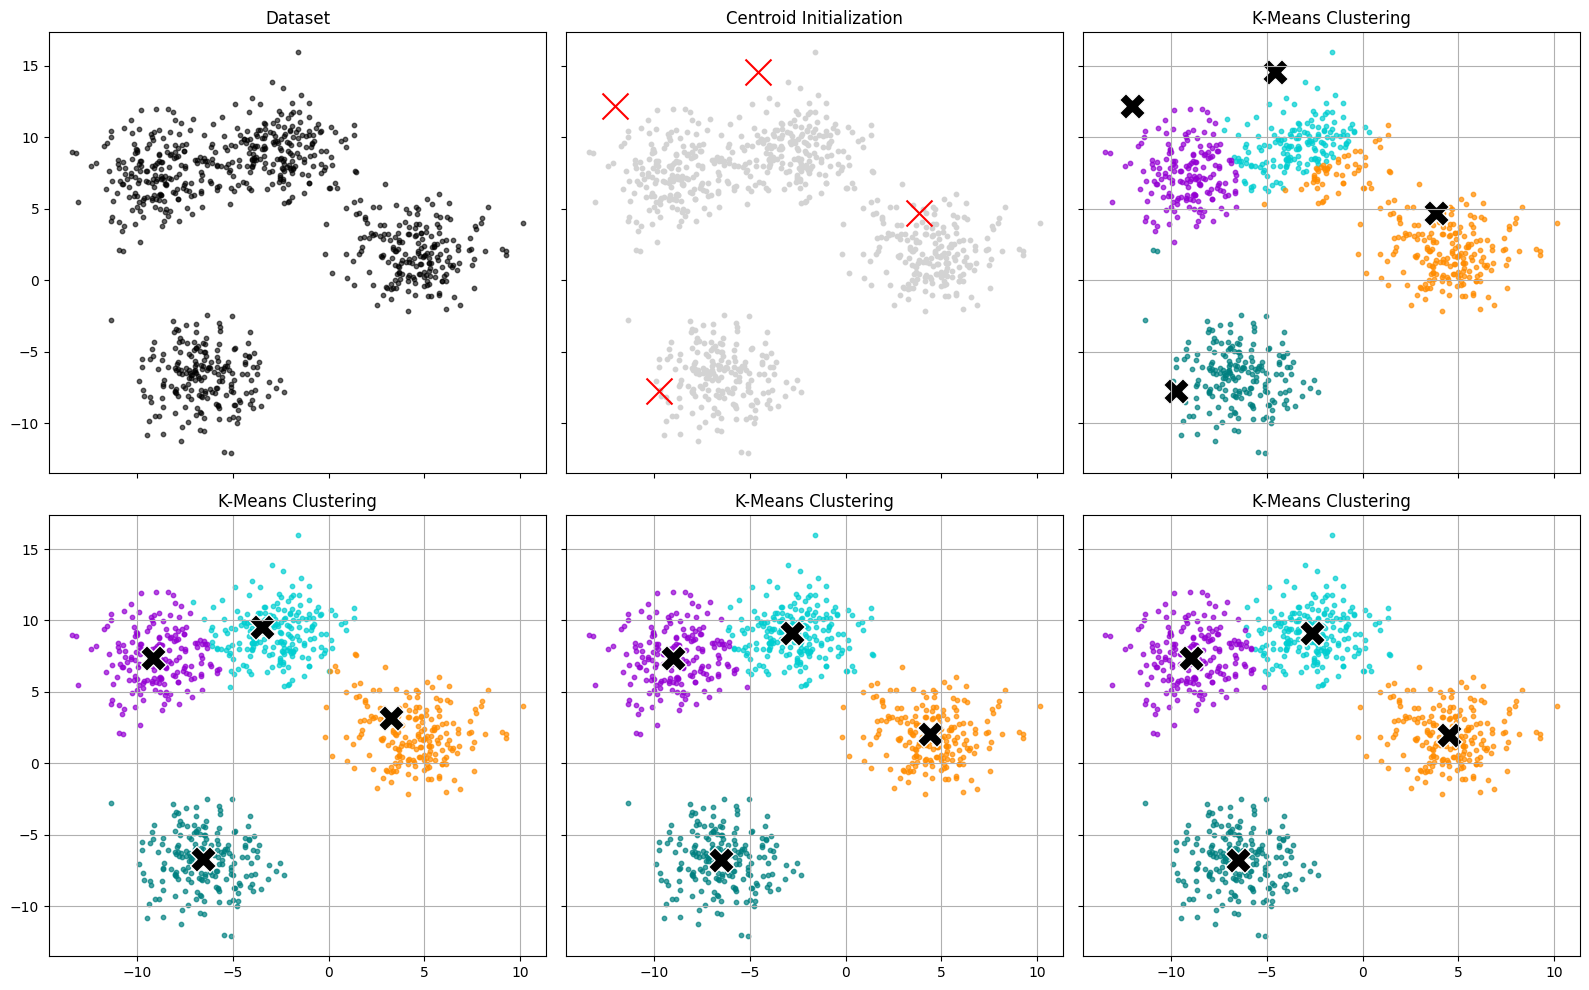

In [5]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(16, 10)
axs[0, 0].scatter(X[:,0],X[:,1], s = 10, c = 'black',alpha=0.6)
axs[0, 0].set_title('Dataset')

np.random.seed(42)
initializeClusterCentroids()

#Now, lets plot the centroids it has initalized
axs[0, 1].set_title('Centroid Initialization')
axs[0, 1].scatter(X[:, 0], X[:, 1], s = 10, c = 'lightgray')
for i in range(k):#for all the clusters
    center = clusters[i]['center'] #its cluster's center
    axs[0, 1].scatter(center[0], center[1], c='red', s=350, marker="x")

#CLUSTERING EPOCH 1
axs[0, 2].set_title('Iteration 1')
assignPointsToCluster(clusters, X)
plotclusters(clusters, axs[0, 2])
shift = updateCluster(clusters)
print("Iteration 1 Shift:", shift)

#CLUSTERING EPOCH 2
axs[1, 0].set_title('Iteration 2')
assignPointsToCluster(clusters, X)
plotclusters(clusters, axs[1, 0])
shift = updateCluster(clusters)
print("Iteration 2 Shift:", shift)

#CLUSTERING EPOCH 3
axs[1, 1].set_title('Iteration 3')
assignPointsToCluster(clusters, X)
plotclusters(clusters, axs[1, 1])
shift = updateCluster(clusters)
print("Iteration 3 Shift:", shift)

#CLUSTERING EPOCH 4
axs[1, 2].set_title('Iteration 4')
assignPointsToCluster(clusters, X)
plotclusters(clusters, axs[1, 2])
shift = updateCluster(clusters)
print("Iteration 4 Shift:", shift)

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

plt.tight_layout()
plt.show()

Let us now try the same thing with different number of clusters. We will also see how initialization matters.

Shape = (1000, 2)
Sample:
[[ -6.30933041  -5.96423098]
 [  2.52861129   0.80644465]
 [ -7.68077969   3.05070898]
 [ -6.03994152  -5.2589385 ]
 [-10.55053251  10.04608086]]


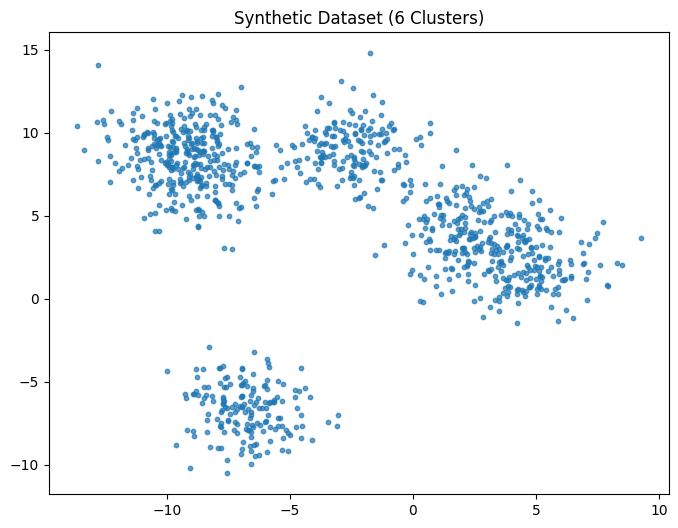

In [6]:
# Generating Synthetic Data

k=6
color=["darkturquoise","darkorange","teal","darkviolet","tomato", "yellowgreen","hotpink","gold"]

X,_=make_blobs(n_samples=1000, n_features=2, centers=k, cluster_std=1.5, random_state=42)
print("Shape = " + str(X.shape))

print("Sample:")
print(X[:5])
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], s=10, alpha=0.7)
plt.title(f"Synthetic Dataset ({k} Clusters)")
plt.show()

Iteration 1 Shift: 16.497803581437967
Iteration 2 Shift: 4.9849615533948635
Iteration 3 Shift: 1.713139573867423
Iteration 4 Shift: 1.2436939118683905


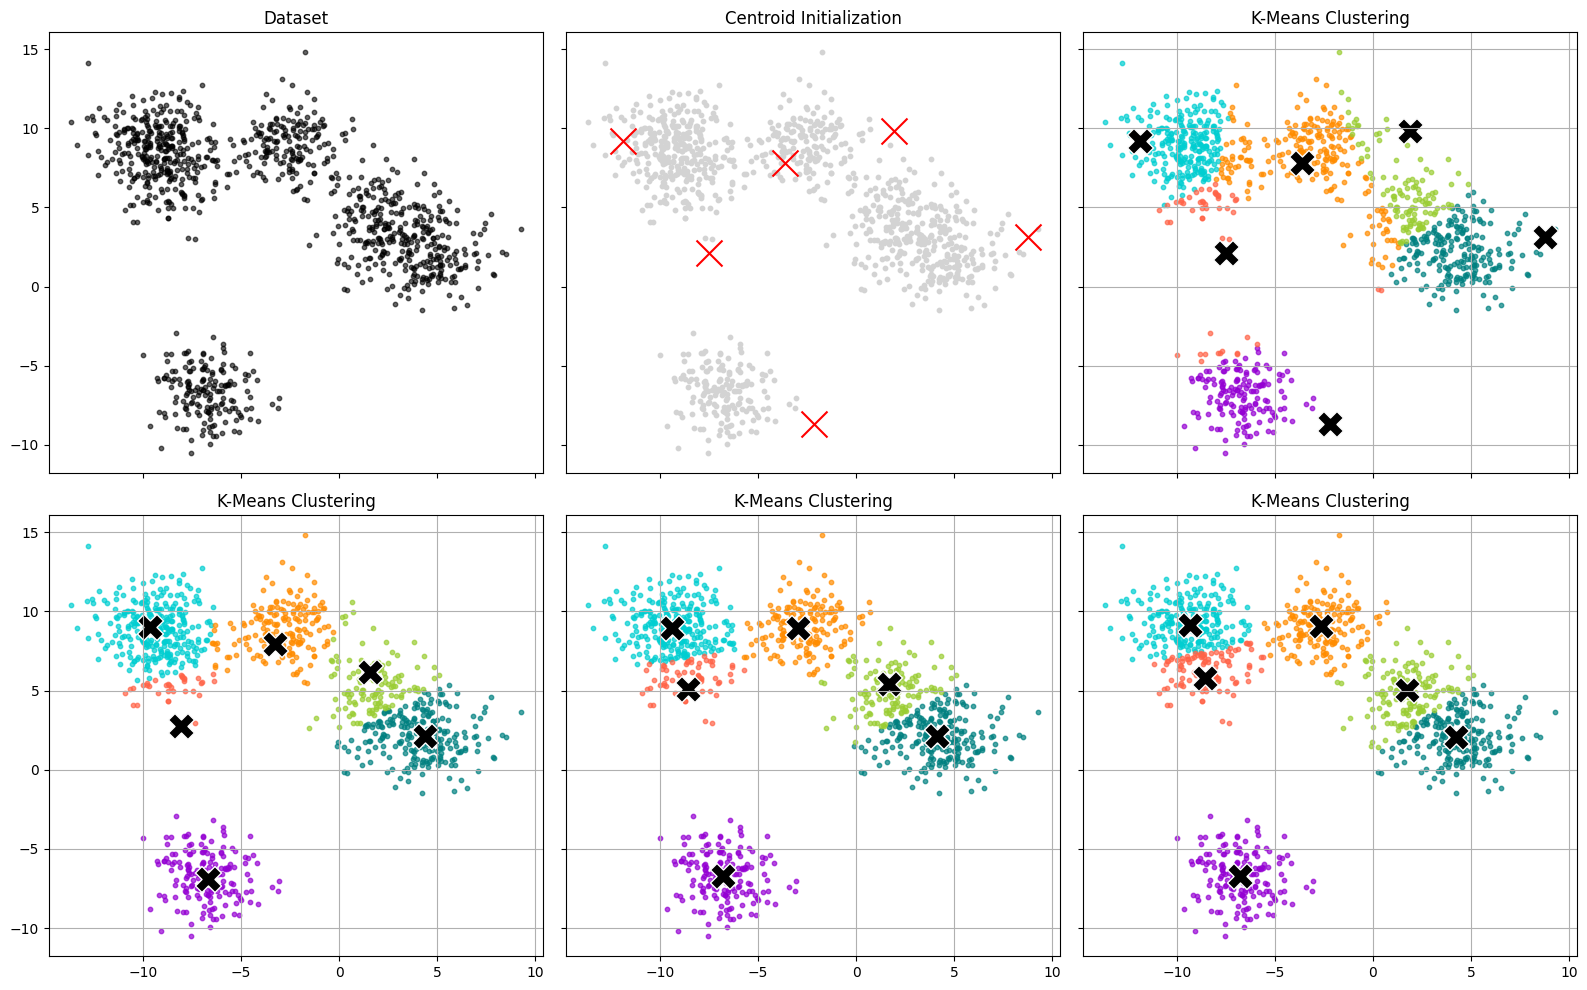

In [7]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(16, 10)
axs[0, 0].scatter(X[:,0],X[:,1], s = 10, c = 'black', alpha=0.6)
axs[0, 0].set_title('Dataset')

## Change initialization here to 'np.random.seed(0)'
np.random.seed(7)
initializeClusterCentroids()

#Now, lets plot the centroids it has initalized
axs[0, 1].set_title('Centroid Initialization')
axs[0, 1].scatter(X[:, 0], X[:, 1], s = 10, c = 'lightgray')
for i in range(k):#for all the clusters
    center = clusters[i]['center'] #its cluster's center
    axs[0, 1].scatter(center[0], center[1], c='red', s=350, marker="x")

#CLUSTERING EPOCH 1
axs[0, 2].set_title('Iteration 1')
assignPointsToCluster(clusters, X)
plotclusters(clusters, axs[0, 2])
print("Iteration 1 Shift:", updateCluster(clusters))

#CLUSTERING EPOCH 2
axs[1, 0].set_title('Iteration 2')
assignPointsToCluster(clusters, X)
plotclusters(clusters, axs[1, 0])
print("Iteration 2 Shift:", updateCluster(clusters))

#CLUSTERING EPOCH 3
axs[1, 1].set_title('Iteration 3')
assignPointsToCluster(clusters, X)
plotclusters(clusters, axs[1, 1])
print("Iteration 3 Shift:", updateCluster(clusters))

#CLUSTERING EPOCH 4
axs[1, 2].set_title('Iteration 4')
assignPointsToCluster(clusters, X)
plotclusters(clusters, axs[1, 2])
print("Iteration 4 Shift:", updateCluster(clusters))

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
plt.tight_layout()
plt.show()

**As you can see, changing the random seed and hence changing the initialization has a large effect on the performance of KMeans.**

Hence our KMeans algo can be run by calling the following function with appropriate X (dataset)

In [8]:
from copy import deepcopy

def run_kmeans(k, X):
  initializeClusterCentroids()
  assignPointsToCluster(clusters, X)
  while (True):
    prev_clusters = deepcopy(clusters)
    updateCluster(clusters)
    assignPointsToCluster(clusters, X)
    if prev_clusters == clusters:
      break
  return clusters

### Kmeans in scikit-learn

Even though implementation of KMeans is easy, using libraries like sklearn allows our code to  be much simpler and faster. The next two cells show how to use it.

Check out all functionalities at https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

In [9]:
from sklearn.cluster import KMeans

kmeans_demo = KMeans(n_clusters=6,init='k-means++',n_init=20, max_iter=500, random_state=42) #random centroid intialization
#kmeans_demo = KMeans() #What if we dont initialize the number of clusters?
#Does smart centroid initialization help?

#Let us fit our synthetic datapoints into the kmeans object
kmeans_demo.fit(X)
print("Inertia:", kmeans_demo.inertia_)
print("Iterations:", kmeans_demo.n_iter_)

print("\nCluster Centers:")
print(kmeans_demo.cluster_centers_)

Inertia: 3765.218806260511
Iterations: 33

Cluster Centers:
[[ 1.99174985  4.25541177]
 [ 4.84021425  1.8358621 ]
 [-6.77731131 -6.68803394]
 [-9.65639831  9.77896354]
 [-2.5225601   9.0172553 ]
 [-8.55275939  6.8638413 ]]


ITERATIONS TO CONVERGE = 33
INERTIA = 3765.218806260511

CLUSTER CENTROIDS =
[[ 1.99174985  4.25541177]
 [ 4.84021425  1.8358621 ]
 [-6.77731131 -6.68803394]
 [-9.65639831  9.77896354]
 [-2.5225601   9.0172553 ]
 [-8.55275939  6.8638413 ]]



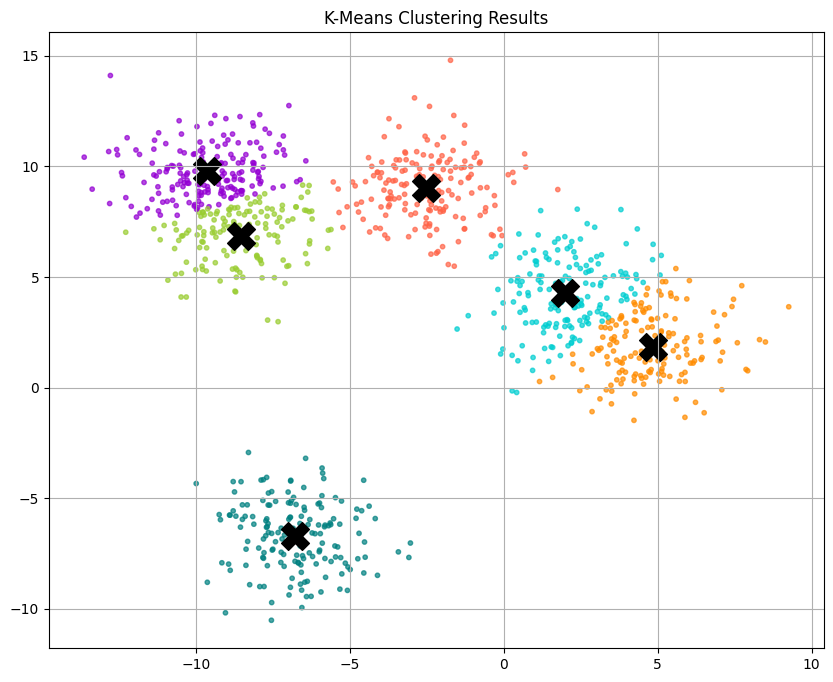

In [10]:
print("ITERATIONS TO CONVERGE =", kmeans_demo.n_iter_)
print("INERTIA =", kmeans_demo.inertia_)
print("\nCLUSTER CENTROIDS =")
print(kmeans_demo.cluster_centers_)
print()

colors_toplot = []
for label in kmeans_demo.labels_:
    colors_toplot.append(color[label])

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0],X[:, 1],c=colors_toplot,s=10,alpha=0.7)

# centroids
plt.scatter(kmeans_demo.cluster_centers_[:, 0],kmeans_demo.cluster_centers_[:, 1],c='black',s=400,marker='X')

plt.title("K-Means Clustering Results")
plt.grid(True)

plt.show()

### KMeans on Digits Dataset (KMeans for labelling)

Here we will attempt to use k-means to try to identify similar digits without using the original label information; this might be similar to a first step in extracting meaning from a new dataset about which you don't have any a priori label information.

In [11]:
from sklearn.datasets import load_digits

digits = load_digits()
digits.data.shape

(1797, 64)

In [12]:
from sklearn.cluster import KMeans

# Perform KMeans
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

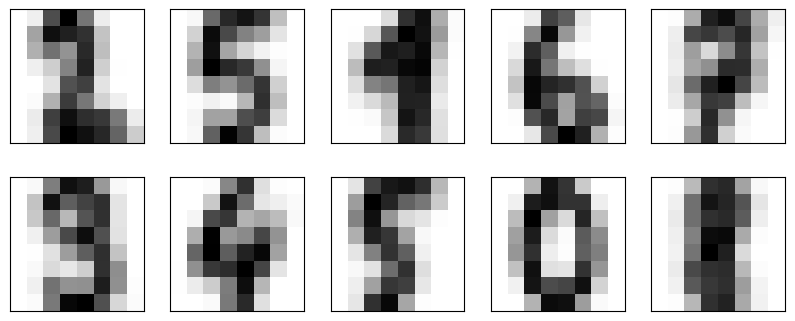

In [13]:
# We can now see how the centers of the clusters formed are

fig, ax = plt.subplots(2, 5, figsize=(10, 4))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

Because k-means knows nothing about the identity of the cluster, the 0–9 labels may be permuted. We can fix this by matching each learned cluster label with the true labels found in them:

In [14]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

Now we can check how accurate our unsupervised clustering was in finding similar digits within the data:

In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

**Hence clustering algorithms like KMeans are highly effective for identifying labels for groups apriori and even a simple KMeans acheives a ~80% accuracy on digit classification.**

The confusion matrix for this looks like:

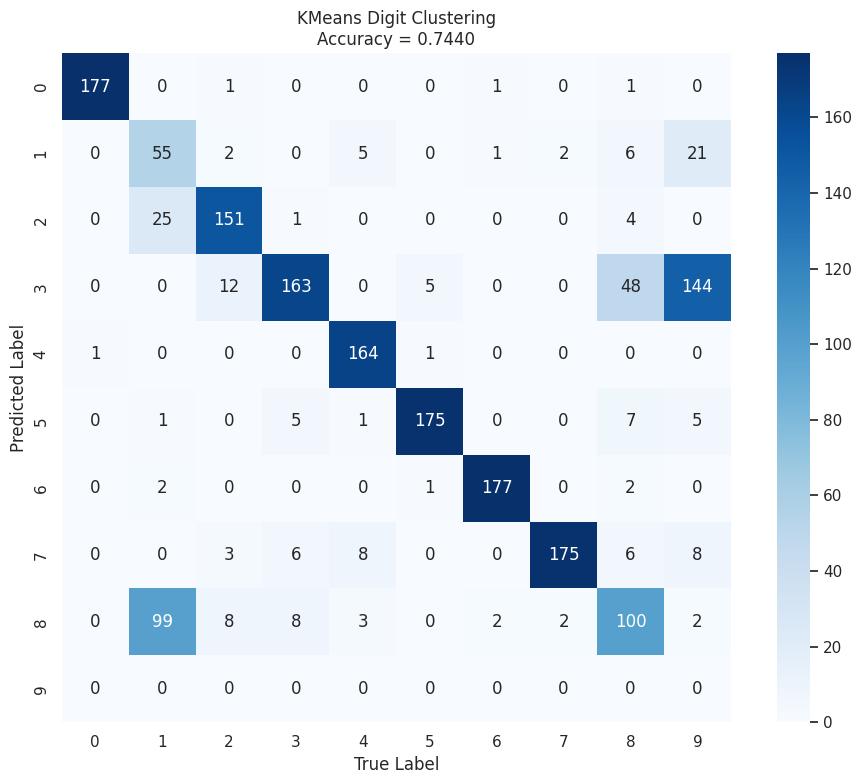

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
sns.set(style="whitegrid")
# Confusion Matrix
mat = confusion_matrix(digits.target, labels)
plt.figure(figsize=(10, 8))
sns.heatmap(mat.T,square=True,annot=True,fmt='d',cmap='Blues',cbar=True,xticklabels=digits.target_names,yticklabels=digits.target_names)
plt.title(f"KMeans Digit Clustering\nAccuracy = {accuracy_score(digits.target, labels):.4f}")

plt.xlabel("True Label")
plt.ylabel("Predicted Label")

plt.tight_layout()
plt.show()

### KMeans on Iris Dataset (Elbow Method)

We will perform KMeans on the famous Iris Dataset which has four features: sepal length, sepal width, petal length, and petal width. The fifth column is for species, which holds the value for these types of plants.

In [17]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from sklearn import datasets

In [18]:
from sklearn.preprocessing import StandardScaler
#import the dataset
iris = datasets.load_iris()
# print(iris.data[:10])
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df['species'] = iris.target
scaler = StandardScaler()
x = scaler.fit_transform(df.iloc[:, 0:4])
print("Dataset Shape:", df.shape)
print("\nFeature Summary:")
print(df.describe())

df.head()


Dataset Shape: (150, 5)

Feature Summary:
       sepal_length  sepal_width  petal_length  petal_width     species
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.057333      3.758000     1.199333    1.000000
std        0.828066     0.435866      1.765298     0.762238    0.819232
min        4.300000     2.000000      1.000000     0.100000    0.000000
25%        5.100000     2.800000      1.600000     0.300000    0.000000
50%        5.800000     3.000000      4.350000     1.300000    1.000000
75%        6.400000     3.300000      5.100000     1.800000    2.000000
max        7.900000     4.400000      6.900000     2.500000    2.000000


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Let us start with assigning the initial number of clusters as k=5.

In [19]:
kmeans5 = KMeans(n_clusters=5)
y_kmeans5 = kmeans5.fit_predict(x)
print(y_kmeans5)

kmeans5.cluster_centers_

[2 2 2 2 2 4 2 2 2 2 4 2 2 2 4 4 4 2 4 4 2 4 2 2 2 2 2 2 2 2 2 2 4 4 2 2 2
 2 2 2 2 0 2 2 4 2 4 2 4 2 1 3 1 0 3 3 3 0 3 0 0 3 0 3 3 3 3 0 0 0 3 3 3 3
 3 3 3 1 3 0 0 0 0 3 3 3 3 0 3 0 0 3 0 0 0 3 3 3 0 3 1 3 1 3 1 1 0 1 3 1 1
 3 1 3 3 1 1 1 1 0 1 3 1 3 1 1 3 3 3 1 1 1 1 3 3 1 1 1 3 1 1 1 3 1 1 1 3 1
 1 3]


array([[-0.42151732, -1.42945216,  0.03937284, -0.05297198],
       [ 1.30885058,  0.17269271,  1.1238431 ,  1.1739526 ],
       [-1.15648001,  0.52663905, -1.31496545, -1.27522335],
       [ 0.30830491, -0.41844657,  0.55056521,  0.50693017],
       [-0.57445998,  1.95749886, -1.27027277, -1.20406322]])

How do we choose the optimal number of clusters? There’s a method called the Elbow method, which is designed to help find the optimal number of clusters in a dataset. So let’s use this method to calculate the optimum value of k. To implement the Elbow method, we need to create some Python code (shown below), and we’ll plot a graph between the number of clusters and the corresponding error value.

This graph generally ends up shaped like an elbow, hence its name:

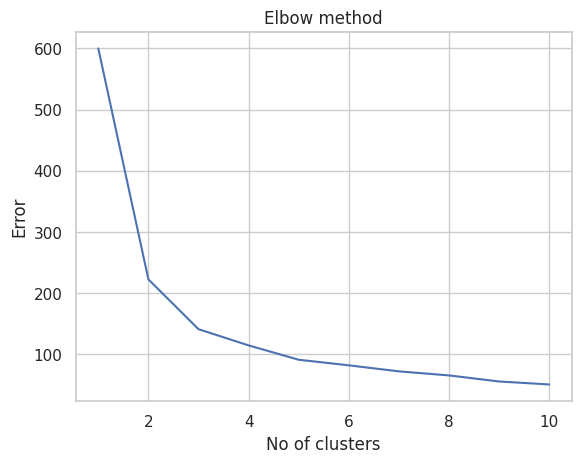

In [20]:
Error =[]
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i).fit(x)
    kmeans.fit(x)
    Error.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 11), Error)
plt.title('Elbow method')
plt.xlabel('No of clusters')
plt.ylabel('Error')
plt.show()

The output graph of the Elbow method shows that the shape of elbow is approximately formed at k=3. The optimal value of k is between 2 and 4, as the elbow-like shape is formed at k=3 in the above graph.

In [21]:
kmeans3 = KMeans(n_clusters=3)
y_kmeans3 = kmeans3.fit_predict(x)
print(y_kmeans3)

kmeans3.cluster_centers_

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 2 0 0 0 2 0
 0 0]


array([[ 1.03359865,  0.00613858,  0.94360463,  0.9725624 ],
       [-1.00206653,  0.90625492, -1.30310821, -1.25634413],
       [-0.16840578, -0.9726981 ,  0.2598706 ,  0.17543327]])

We can now visualize the clustering in two dimensions instead of the original four.

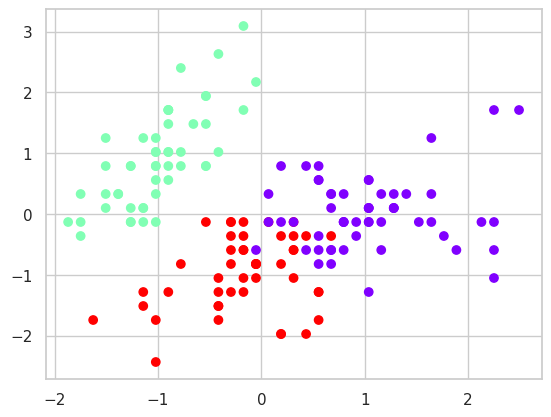

In [22]:
plt.scatter(x[:,0], x[:,1], c=y_kmeans3, cmap='rainbow')

## Points to think about

1. Is feature scaling essential for KMeans as it is for most ML algos? Explain.
2. What are ways to prevent initialization variation in KMeans?
3. What is the training and testing complexity of KMeans?

### 1. Is feature scaling essential for K-Means?

**Yes, usually.** K-Means uses **Euclidean distance** to assign points to clusters. If one feature has a much larger range than others, it dominates the distance calculation.

Without scaling, K-Means will mostly cluster based on income and largely ignore sepal length.

Benefits of scaling:
* All features contribute equally.
* Better cluster quality.
* Faster convergence.

Common methods:

* StandardScaler
* MinMaxScaler


### 2. What are ways to prevent initialization variation in K-Means?

K-Means can produce different results because centroids are initialized randomly.

To reduce variation:

* K-Means++ initialization
  * Chooses initial centroids intelligently.
  * Most commonly used solution.
* Increase n_init
  * Run K-Means multiple times and keep the best result.

* Fix random_state
  * Makes results reproducible.

* Run multiple experiments
  * Compare inertia and cluster quality across runs.



### 3. What is the training and testing complexity of K-Means?
Each iteration:

* Compute distance of every point to every centroid → O(nkd)
* Update centroids → O(nd)

Training complexity grows with:

* More data points
* More clusters
* More features
* More iterations
Testing / Prediction Complexity

For a new point:
* Compute distance to all k centroids

So K-Means training is relatively expensive, while prediction is much faster.


## References and resources

1. https://towardsdatascience.com/k-means-clustering-algorithm-applications-evaluation-methods-and-drawbacks-aa03e644b48a
2. https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/
3. https://en.wikipedia.org/wiki/K-means_clustering
4. https://jakevdp.github.io/PythonDataScienceHandbook/05.11-k-means.html
5. https://heartbeat.fritz.ai/k-means-clustering-using-sklearn-and-python-4a054d67b187

# Hierarchical Clustering

KMeans is an iterative process. It will keep on running until the centroids of newly formed clusters do not change or the maximum number of iterations are reached.

But there are certain challenges with K-means. It always tries to make clusters of the same size. Also, we have to decide the number of clusters at the beginning of the algorithm. Ideally, we would not know how many clusters should we have, in the beginning of the algorithm and hence it a challenge with K-means.

This is a gap hierarchical clustering bridges with aplomb. It takes away the problem of having to pre-define the number of clusters. Sounds like a dream! So, let’s see what hierarchical clustering is and how it improves on K-means.

## What is Hierarchical Clustering?

Let’s say we have the below points and we want to cluster them into groups:

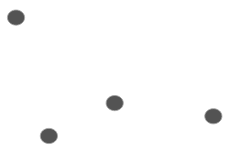

We can assign each of these points to a separate cluster:

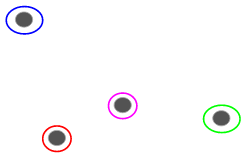

Now, based on the similarity of these clusters, we can combine the most similar clusters together and repeat this process until only a single cluster is left:

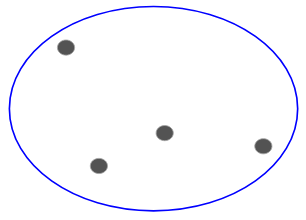

We are essentially building a hierarchy of clusters. That’s why this algorithm is called hierarchical clustering. I will discuss how to decide the number of clusters in a later section. For now, let’s look at the different types of hierarchical clustering.

## Agglomerative Hierarchical Clustering

In this technique, initially each data point is considered as an individual cluster. At each iteration, the similar clusters merge with other clusters until one cluster or K clusters are formed.

The basic algorithm of Agglomerative is straight forward.

    Compute the proximity matrix
    Let each data point be a cluster
    Repeat: Merge the two closest clusters and update the proximity matrix
    Until only a single cluster remains

To understand better let’s see a pictorial representation of the Agglomerative Hierarchical clustering Technique. Lets say we have six data points {A,B,C,D,E,F}.

    Step- 1: In the initial step, we calculate the proximity of individual points and consider all the six data points as individual clusters as shown in the image below.

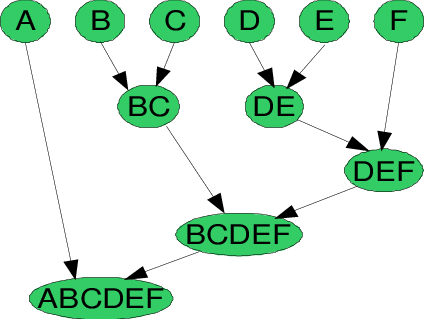

    Step- 2: In step two, similar clusters are merged together and formed as a single cluster. Let’s consider B,C, and D,E are similar clusters that are merged in step two. Now, we’re left with four clusters which are A, BC, DE, F.
    Step- 3: We again calculate the proximity of new clusters and merge the similar clusters to form new clusters A, BC, DEF.
    Step- 4: Calculate the proximity of the new clusters. The clusters DEF and BC are similar and merged together to form a new cluster. We’re now left with two clusters A, BCDEF.
    Step- 5: Finally, all the clusters are merged together and form a single cluster.

Here is what this process in action looks like.

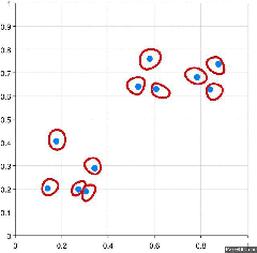

## Dendograms

A Dendrogram is a type of tree diagram showing hierarchical relationships between different sets of data.

As already said a Dendrogram contains the memory of hierarchical clustering algorithm, so just by looking at the Dendrgram you can tell how the cluster is formed.

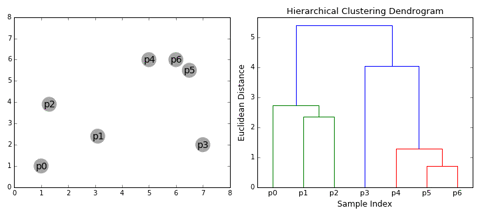



Note:-

    Distance between data points represents dissimilarities.
    Height of the blocks represents the distance between clusters.

So you can observe from the above figure that initially P5 and P6 which are closest to each other by any other point are combined into one cluster followed by P4 getting merged into the same cluster(C2). Then P1and P2 gets combined into one cluster followed by P0 getting merged into the same cluster(C4). Now P3 gets merged in cluster C2 and finally, both clusters get merged into one.

**How do you decide when to stop merging the clusters?**

You cut the dendrogram tree with a horizontal line at a height where the line can traverse the maximum distance up and down without intersecting the merging point.

For example in the below figure L3 can traverse maximum distance up and down without intersecting the merging points. So we draw a horizontal line and the number of verticle lines it intersects is the optimal number of clusters.

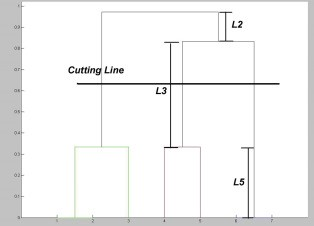

In [23]:
# load necessary files

!curl -L -o 'Mall_Customers.csv' 'https://drive.google.com/uc?export=download&id=1sgy48AZi0It6VBMQXTJbRLjlIg6E7HlY'
!curl -L -o 'Wholesale customers data.csv' 'https://drive.google.com/uc?export=download&id=1Jvqxa_KkjX8nZ5oxXe_6CzQ6aI3vVIZV'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  4286  100  4286    0     0   3853      0  0:00:01  0:00:01 --:--:-- 4185k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 15021  100 15021    0     0  16902      0 --:--:-- --:--:-- --:--:-- 14.3M


### Agglomerative Clustering on Mall Visitors Database

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Let's load the dataset

In [25]:
dataset = pd.read_csv('./Mall_Customers.csv')

In [26]:
X = dataset.iloc[:, [3, 4]].values

Next, we need to choose the number of clusters and for doing this we’ll use Dendrograms.

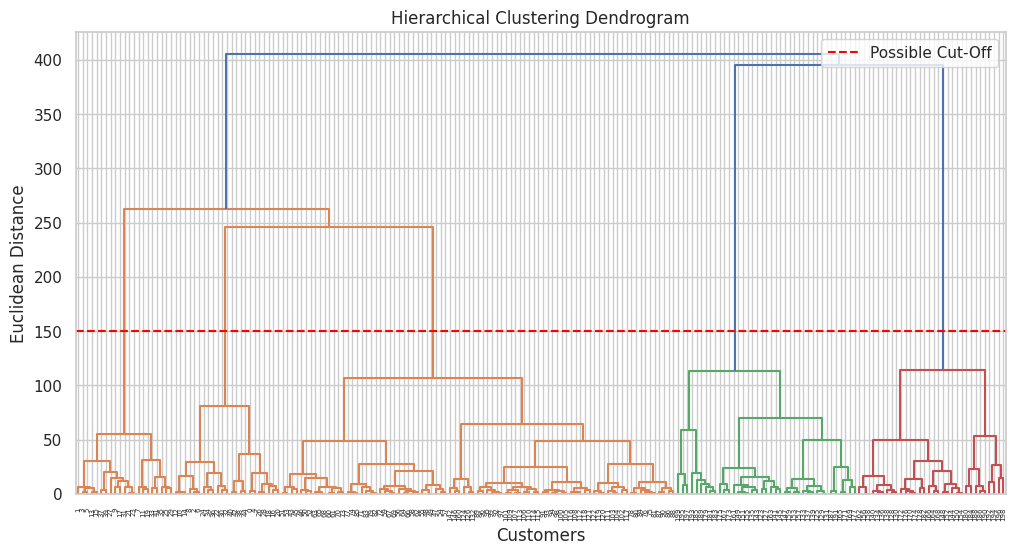

In [27]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X,method='ward'))

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')

plt.axhline(y=150,color='red',linestyle='--',label='Possible Cut-Off')

plt.legend()
plt.grid(True)

plt.show()

As we have already discussed to choose the number of clusters we draw a horizontal line to the longest line that traverses maximum distance up and down without intersecting the merging points. So we draw a horizontal line and the number of verticle lines it intersects is the optimal number of clusters.

In this case, it's 5. So let's fit our Agglomerative model with 5 clusters.

In [28]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

hc = AgglomerativeClustering(n_clusters=6,      linkage='complete')
y_hc = hc.fit_predict(X)

print("Number of Clusters:", len(np.unique(y_hc)))
print("Silhouette Score:", silhouette_score(X, y_hc))

Number of Clusters: 6
Silhouette Score: 0.5436661823351217


Visualize the results.

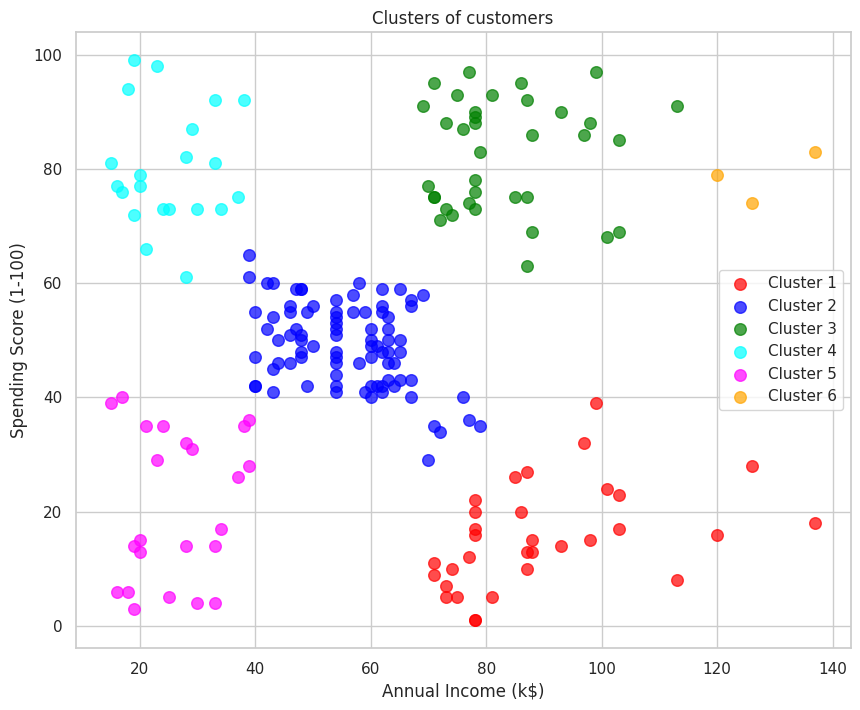

In [29]:
# Visualising the clusters
plt.figure(figsize=(10, 8))
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 70, c = 'red', alpha=0.7, label='Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 70, c = 'blue',  alpha=0.7, label='Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 70, c = 'green', alpha=0.7, label='Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 70, c = 'cyan', alpha=0.7, label='Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 70, c = 'magenta', alpha=0.7, label='Cluster 5')
if len(np.unique(y_hc)) > 5:
    plt.scatter(X[y_hc == 5, 0], X[y_hc == 5, 1],
                s=70, c='orange', alpha=0.7, label='Cluster 6')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend()
plt.show()

### Solving the Wholesale Customer Segmentation problem using Hierarchical Clustering

We will be working on a wholesale customer segmentation problem. The aim of this problem is to segment the clients of a wholesale distributor based on their annual spending on diverse product categories, like milk, grocery, region, etc.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [31]:
data = pd.read_csv('./Wholesale customers data.csv')
print("Dataset Shape:", data.shape)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nStatistical Summary:")
print(data.describe())

print("\nFirst 5 Rows:")
display(data.head())

Dataset Shape: (440, 8)

Missing Values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Statistical Summary:
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper    Delicassen  
count    

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [33]:
from sklearn.preprocessing import StandardScaler

# Using StandardScaler instead of normalize
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled,columns=data.columns)

print("Scaled Data Shape:", data_scaled.shape)
print("\nScaled Data Summary:")
print(data_scaled.describe())

data_scaled.head()

Scaled Data Shape: (440, 8)

Scaled Data Summary:
            Channel        Region         Fresh        Milk       Grocery  \
count  4.400000e+02  4.400000e+02  4.400000e+02  440.000000  4.400000e+02   
mean   1.614870e-17  3.552714e-16 -3.431598e-17    0.000000 -4.037175e-17   
std    1.001138e+00  1.001138e+00  1.001138e+00    1.001138  1.001138e+00   
min   -6.902971e-01 -1.995342e+00 -9.496831e-01   -0.778795 -8.373344e-01   
25%   -6.902971e-01 -7.023369e-01 -7.023339e-01   -0.578306 -6.108364e-01   
50%   -6.902971e-01  5.906683e-01 -2.767602e-01   -0.294258 -3.366684e-01   
75%    1.448652e+00  5.906683e-01  3.905226e-01    0.189092  2.849105e-01   
max    1.448652e+00  5.906683e-01  7.927738e+00    9.183650  8.936528e+00   

             Frozen  Detergents_Paper    Delicassen  
count  4.400000e+02      4.400000e+02  4.400000e+02  
mean   3.633457e-17      2.422305e-17 -8.074349e-18  
std    1.001138e+00      1.001138e+00  1.001138e+00  
min   -6.283430e-01     -6.044165e-01 -5

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.448652,0.590668,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,1.448652,0.590668,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,1.448652,0.590668,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,-0.690297,0.590668,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,1.448652,0.590668,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


Different types of linkages -

1. 'ward’ minimizes the variance of the clusters being merged.

2. ‘average’ uses the average of the distances of each observation of the two sets.

3. ‘complete’ or ‘maximum’ linkage uses the maximum distances between all observations of the two sets.

4. ‘single’ uses the minimum of the distances between all observations of the two sets.

Let us visualize the different types of linkages.



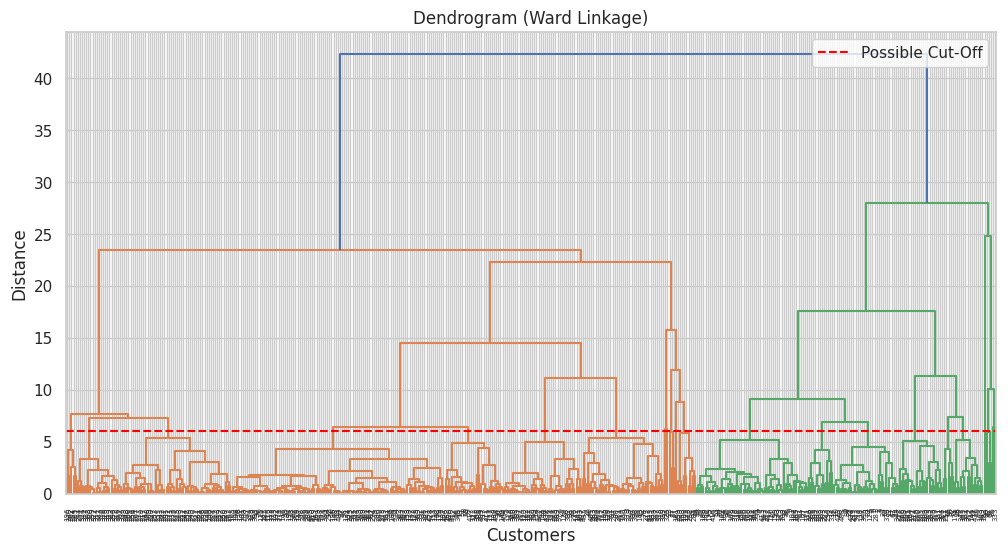

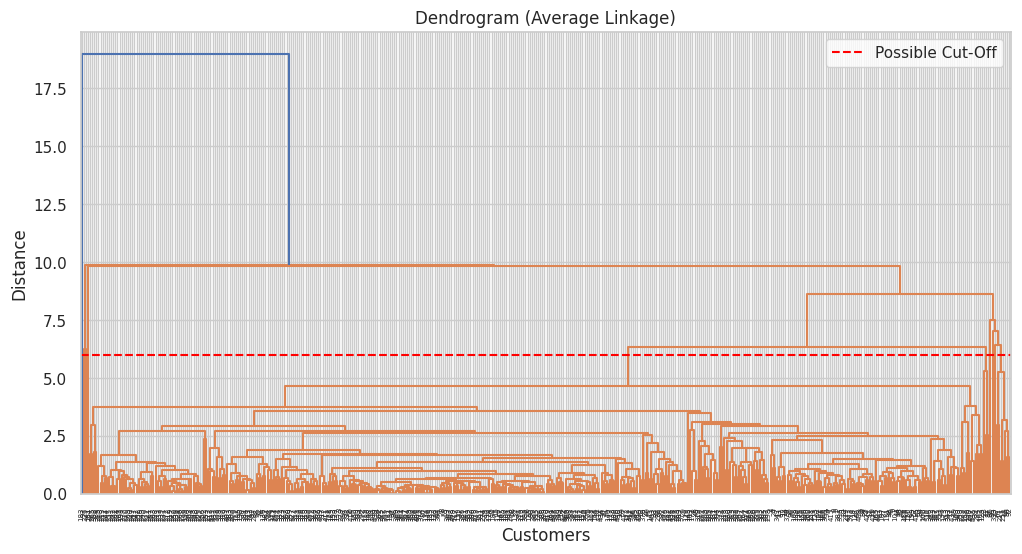

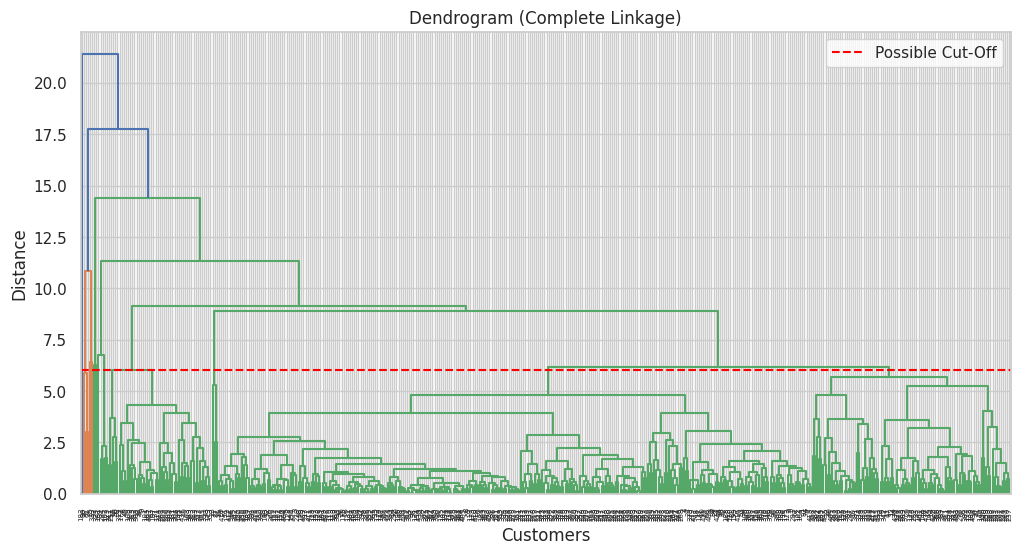

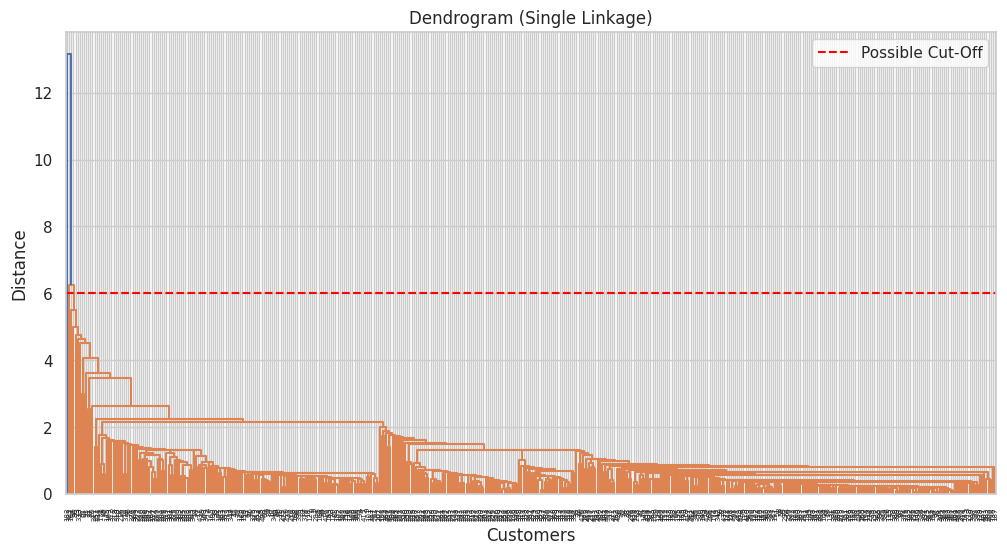

In [34]:
import scipy.cluster.hierarchy as shc
linkages = ['ward', 'average','complete','single']
for linkage in linkages:
  plt.figure(figsize=(12, 6))
  dend = shc.dendrogram(shc.linkage(data_scaled,method=linkage))

  plt.title(f'Dendrogram ({linkage.capitalize()} Linkage)')
  plt.xlabel('Customers')
  plt.ylabel('Distance')
  plt.axhline(y=6,color='red',linestyle='--',label='Possible Cut-Off')

  plt.legend()
  plt.grid(True)

  plt.show()

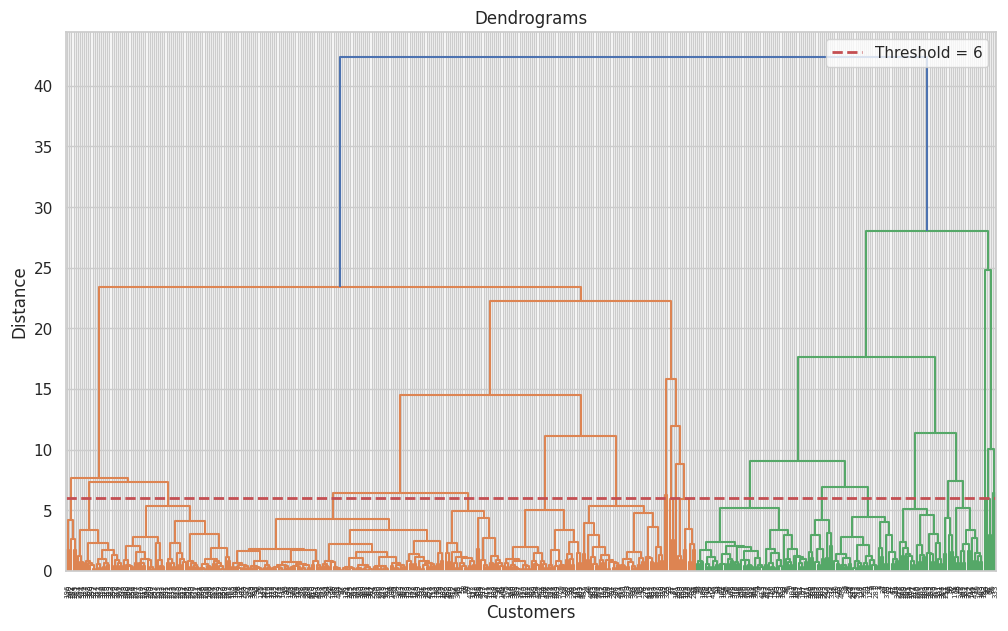

In [35]:
threshold = 6 #@param {type:"slider", min:0, max:100, step:1}

plt.figure(figsize=(12, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.axhline(y=threshold, color='r', linestyle='--',linewidth=2,
    label=f'Threshold = {threshold}')
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

cluster = AgglomerativeClustering(n_clusters=3,linkage='complete')

labels = cluster.fit_predict(data_scaled)

print("Number of Clusters:", len(np.unique(labels)))
print("Silhouette Score:", silhouette_score(data_scaled, labels))

# Cluster sizes
print("\nCluster Counts:")
print(pd.Series(labels).value_counts().sort_index())

Number of Clusters: 3
Silhouette Score: 0.7037718767373393

Cluster Counts:
0    434
1      1
2      5
Name: count, dtype: int64


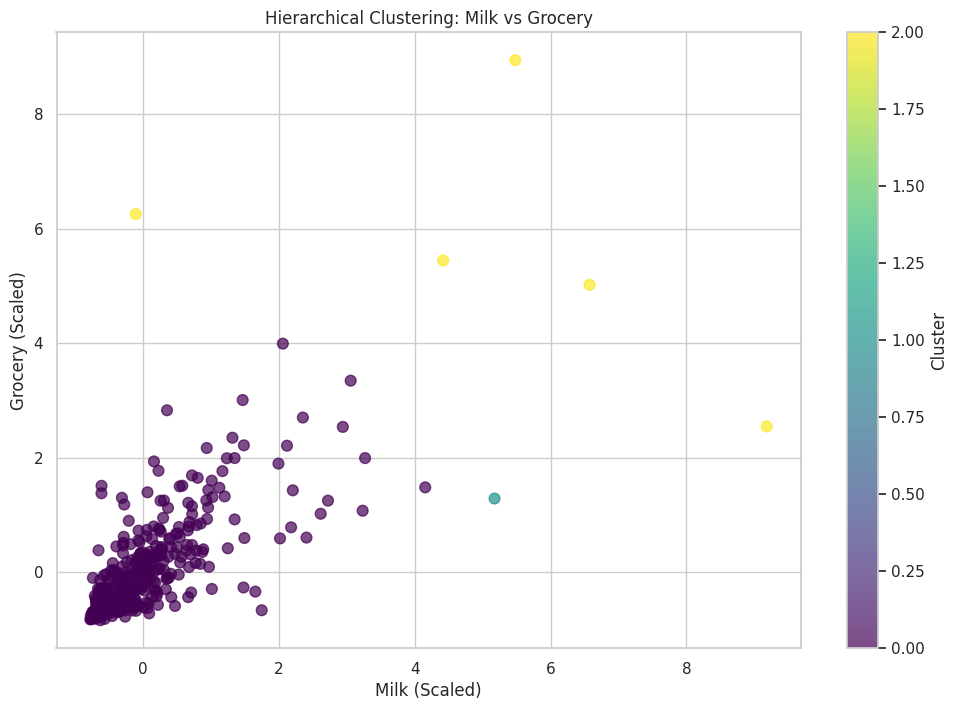

In [37]:
plt.figure(figsize=(12, 8))

plt.scatter(data_scaled['Milk'],data_scaled['Grocery'],c=labels,s=60,alpha=0.7,cmap='viridis')

plt.title('Hierarchical Clustering: Milk vs Grocery')
plt.xlabel('Milk (Scaled)')
plt.ylabel('Grocery (Scaled)')
plt.grid(True)

plt.colorbar(label='Cluster')

plt.show()

## Divisive Hierarchical Clustering

In Divisive or DIANA(DIvisive ANAlysis Clustering) is a top-down clustering method where we assign all of the observations to a single cluster and then partition the cluster to two least similar clusters. Finally, we proceed recursively on each cluster until there is one cluster for each observation. So this clustering approach is exactly opposite to Agglomerative clustering.

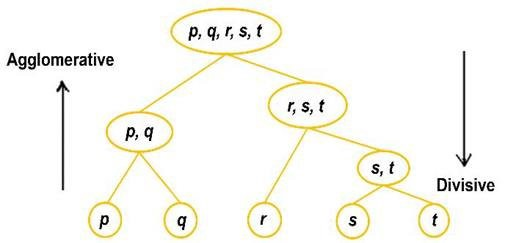

There is evidence that divisive algorithms produce more accurate hierarchies than agglomerative algorithms in some circumstances but is conceptually more complex.

In both agglomerative and divisive hierarchical clustering, users need to specify the desired number of clusters as a termination condition(when to stop merging).

Divisive clustering methods are fairly complicated to implement, so we will not do that here. You can check out open source implementations like https://github.com/div338/Divisive-Clustering-Analysis-Program-DIANA- for further details.

## Excercises

1. What is the need for hierarchical clustering and its advantages over KMeans?
2. What is the advantages of Density Based Clustering over KMeans?

1. Need for Hierarchical Clustering and its advantages over K-Means

**Need:**
Hierarchical clustering is used when the number of clusters is unknown and when we want to understand the hierarchical relationship between data points.

Advantages over K-Means:

* Does not require specifying K beforehand.
* Produces a dendrogram, which helps visualize cluster relationships.
* Can detect nested clusters.
* Works well for small datasets.
* Different linkage methods (Ward, Complete, Average, Single) provide flexibility.

Disadvantages:

* Computationally expensive for large datasets.
* Once clusters are merged/split, the decision cannot be undone.


2. Advantages of Density-Based Clustering over K-Means

Examples: DBSCAN, OPTICS

Advantages:

* Does not require specifying the number of clusters.
* Can identify arbitrarily shaped clusters.
* Handles noise and outliers effectively.
* More robust when clusters have different sizes and densities.

K-Means limitations:

* Requires K in advance.
* Sensitive to outliers.
* Assumes roughly spherical clusters.
* Sensitive to centroid initialization.



## Conclusion


Hierarchical clustering is a very useful way of segmentation. The advantage of not having to pre-define the number of clusters gives it quite an edge over k-Means. However, it doesn't work well when we have huge amount of data.

## Resources and References

1. https://en.wikipedia.org/wiki/Hierarchical_clustering
2. https://www.analyticsvidhya.com/blog/2019/05/beginners-guide-hierarchical-clustering/
3. https://towardsdatascience.com/understanding-the-concept-of-hierarchical-clustering-technique-c6e8243758ec
4. https://www.kdnuggets.com/2019/09/hierarchical-clustering.html